# Geo Snap — Task 3: Environmental Insights (Bonus)

Goes beyond classification: derives interpretable **environmental indicators** from
the 13 Sentinel-2 bands and reads the landscape with them. Four insights:

1. **Environmental fingerprint per class** — NDVI / NDWI / NDBI / NDMI signatures.
2. **Urban structure** — separating Residential vs Industrial by built-up intensity (NDBI).
3. **Agricultural condition** — vegetation vigour & moisture gradients across crop classes.
4. **Physical validation of the test predictions** — the novel part: the test set is
   unlabelled, so we can't check accuracy, but we *can* check that each predicted
   class has physically-consistent spectral indices (predicted water → high NDWI,
   predicted forest → high NDVI). This validates the model's test output without labels.

Indices used (all standard remote-sensing formulas):
`NDVI=(NIR-Red)/(NIR+Red)`, `NDWI=(Green-NIR)/(Green+NIR)`,
`NDBI=(SWIR1-NIR)/(SWIR1+NIR)`, `NDMI=(NIR-SWIR1)/(NIR+SWIR1)`.

## 1. Setup

In [1]:
!pip install -q rasterio
import glob, json, os, shutil
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

try:
    import rasterio
    def read_tif(p):
        with rasterio.open(p) as s: return s.read().astype("float32")
except Exception:
    import tifffile
    def read_tif(p):
        a = tifffile.imread(p).astype("float32")
        return a.transpose(2, 0, 1) if a.ndim == 3 else a

## 2. Config & data

In [6]:
DRIVE_SRC  = "/content/drive/MyDrive/GeoSnap"               # label_map.json + ms_predictions.csv
DRIVE_DATA = "/content/drive/MyDrive/EuroSAT_Dataset.zip"   # the image zip

MS_VAL_DIR  = "data/EuroSATallBands/val"
MS_TEST_DIR = "data/EuroSATallBands_test_flat"
LABEL_MAP   = DRIVE_SRC + "/label_map.json"
MS_PRED_CSV = DRIVE_SRC + "/ms_predictions.csv"          # copied from GeoSnap if not local

MAX_PER_CLASS = 150     # val patches per class for the index stats
MAX_TEST      = 100     # test patches per predicted class for validation

In [7]:
from google.colab import drive
drive.mount("/content/drive")
os.makedirs("data", exist_ok=True)
if not os.path.isdir(MS_VAL_DIR):
    os.system(f'unzip -nq "{DRIVE_DATA}" -d data')
if not os.path.exists(MS_PRED_CSV) and os.path.exists(os.path.join(DRIVE_SRC, MS_PRED_CSV)):
    shutil.copy(os.path.join(DRIVE_SRC, MS_PRED_CSV), MS_PRED_CSV)

c2i = json.load(open(LABEL_MAP))
classes = sorted(c2i, key=lambda k: c2i[k])
for p in [MS_VAL_DIR, MS_TEST_DIR, LABEL_MAP, MS_PRED_CSV]:
    print(f"{'OK     ' if os.path.exists(p) else 'MISSING'}  {p}")
print(classes)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
OK       data/EuroSATallBands/val
OK       data/EuroSATallBands_test_flat
OK       /content/drive/MyDrive/GeoSnap/label_map.json
OK       /content/drive/MyDrive/GeoSnap/ms_predictions.csv
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 3. Spectral index functions

In [8]:
RED, GREEN, NIR, SWIR1, SWIR2 = 3, 2, 7, 11, 12     # B04, B03, B08, B11, B12

def indices(arr):
    """arr: (13,H,W) -> dict of per-pixel index maps."""
    eps = 1e-6
    red, green, nir, swir1 = arr[RED], arr[GREEN], arr[NIR], arr[SWIR1]
    return {
        "NDVI": (nir - red)   / (nir + red   + eps),   # vegetation vigour
        "NDWI": (green - nir) / (green + nir + eps),   # open water
        "NDBI": (swir1 - nir) / (swir1 + nir + eps),   # built-up / impervious
        "NDMI": (nir - swir1) / (nir + swir1 + eps),   # vegetation moisture
    }

def index_table(root, classes, max_per_class):
    rows = []
    for c in tqdm(classes, desc="val indices"):
        for fp in sorted(glob.glob(os.path.join(root, c, "*.tif")))[:max_per_class]:
            idx = indices(read_tif(fp))
            rows.append({"class": c, **{k: float(v.mean()) for k, v in idx.items()}})
    return pd.DataFrame(rows)

vdf = index_table(MS_VAL_DIR, classes, MAX_PER_CLASS)
print(vdf.groupby("class")[["NDVI", "NDWI", "NDBI", "NDMI"]].mean().round(3))

val indices:   0%|          | 0/10 [00:00<?, ?it/s]

                       NDVI   NDWI   NDBI   NDMI
class                                           
AnnualCrop            0.367 -0.390 -0.282  0.282
Forest                0.708 -0.566 -0.662  0.662
HerbaceousVegetation  0.383 -0.372 -0.248  0.248
Highway               0.452 -0.396 -0.367  0.367
Industrial            0.218 -0.200 -0.168  0.168
Pasture               0.659 -0.546 -0.550  0.550
PermanentCrop         0.384 -0.387 -0.250  0.250
Residential           0.334 -0.310 -0.212  0.212
River                 0.314 -0.194 -0.481  0.481
SeaLake              -0.257  0.464 -0.761  0.761


## 4. Insight 1 — Environmental fingerprint per class

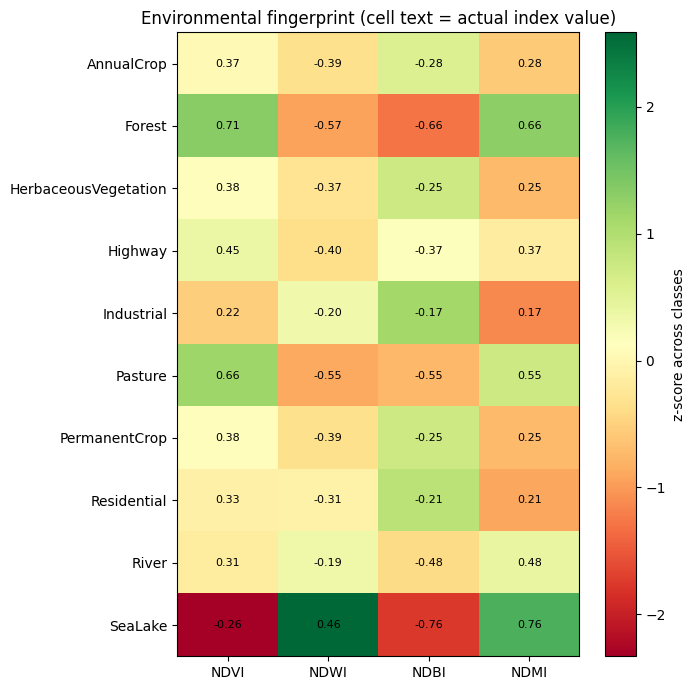

In [9]:
prof = vdf.groupby("class")[["NDVI", "NDWI", "NDBI", "NDMI"]].mean().reindex(classes)
z = (prof - prof.mean()) / (prof.std() + 1e-9)     # z-score per index for readable colour

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(z.values, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(4)); ax.set_xticklabels(prof.columns)
ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes)
for i in range(len(classes)):
    for j in range(4):
        ax.text(j, i, f"{prof.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Environmental fingerprint (cell text = actual index value)")
plt.colorbar(im, label="z-score across classes"); plt.tight_layout()
plt.savefig("env_fingerprint.png", dpi=150, bbox_inches="tight"); plt.show()

*Interpretation.* Each land type has a distinct multi-index signature: SeaLake/River
are the only classes with positive NDWI; Forest/HerbaceousVegetation peak on NDVI/NDMI;
Industrial/Residential peak on NDBI and bottom out on NDVI. This single figure
summarises *what each class is* environmentally, not just spectrally — and the rows
that look similar are exactly the ones the classifier confuses (§ ties back to Task 2).

## 5. Insight 2 — Urban structure: Residential vs Industrial (NDBI)

/tmp/ipykernel_546/3167144253.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  a.boxplot([vdf[vdf["class"] == c][met].values for c in urban], labels=urban)
/tmp/ipykernel_546/3167144253.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  a.boxplot([vdf[vdf["class"] == c][met].values for c in urban], labels=urban)


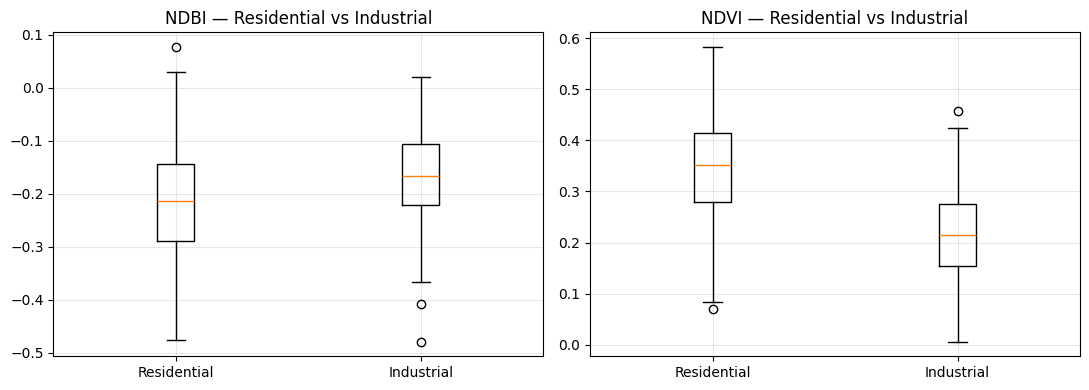

              NDBI   NDVI   NDMI
class                           
Industrial  -0.168  0.218  0.168
Residential -0.212  0.334  0.212


In [10]:
urban = ["Residential", "Industrial"]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, met in zip(ax, ["NDBI", "NDVI"]):
    a.boxplot([vdf[vdf["class"] == c][met].values for c in urban], labels=urban)
    a.set_title(f"{met} — Residential vs Industrial"); a.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("urban_ndbi.png", dpi=150, bbox_inches="tight"); plt.show()
print(vdf[vdf["class"].isin(urban)].groupby("class")[["NDBI", "NDVI", "NDMI"]].mean().round(3))

*Interpretation.* Industrial patches sit higher on NDBI and lower on NDVI than
Residential — more impervious built-up surface, less interspersed vegetation. Residential
land mixes rooftops with gardens/street trees, raising its NDVI and softening NDBI. This
is a real urban-planning signal: NDBI alone gives a built-up-intensity gradient that
distinguishes the two without any labels — useful for mapping imperviousness / urban heat
risk.

## 6. Insight 3 — Agricultural condition: vigour & moisture

/tmp/ipykernel_546/4223054223.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  a.boxplot([vdf[vdf["class"] == c][met].values for c in ag], labels=ag)
/tmp/ipykernel_546/4223054223.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  a.boxplot([vdf[vdf["class"] == c][met].values for c in ag], labels=ag)


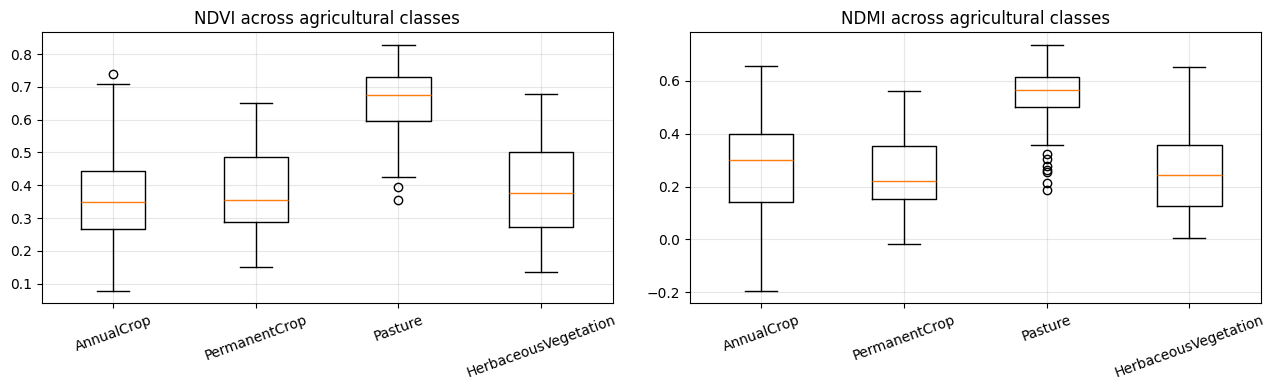

                       NDVI          NDMI       
                       mean    std   mean    std
class                                           
AnnualCrop            0.367  0.146  0.282  0.183
HerbaceousVegetation  0.383  0.141  0.248  0.150
Pasture               0.659  0.099  0.550  0.101
PermanentCrop         0.384  0.119  0.250  0.120


In [11]:
ag = ["AnnualCrop", "PermanentCrop", "Pasture", "HerbaceousVegetation"]
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for a, met in zip(ax, ["NDVI", "NDMI"]):
    a.boxplot([vdf[vdf["class"] == c][met].values for c in ag], labels=ag)
    a.set_title(f"{met} across agricultural classes"); a.tick_params(axis="x", rotation=20); a.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("agri_health.png", dpi=150, bbox_inches="tight"); plt.show()
print(vdf[vdf["class"].isin(ag)].groupby("class")[["NDVI", "NDMI"]].agg(["mean", "std"]).round(3))

*Interpretation.* NDVI spread *within* a crop class is itself a signal — it reflects
growth stage and canopy density, i.e. a crop-health gradient an operational monitoring
system would track over time. PermanentCrop tends to higher, more stable NDVI/NDMI
(persistent woody canopy) than AnnualCrop (bare-soil-to-canopy cycle), which is the
physical reason these two overlap in single-snapshot imagery but separate with phenology.

## 7. Insight 4 — Physical validation of the test predictions (no labels needed)

In [12]:
pred = pd.read_csv(MS_PRED_CSV)
stem2path = {os.path.splitext(os.path.basename(p))[0]: p
             for p in glob.glob(os.path.join(MS_TEST_DIR, "*.tif"))}

rows = []
for label, grp in tqdm(pred.groupby("predicted_label"), desc="test validation"):
    acc = {"NDVI": [], "NDWI": [], "NDBI": [], "NDMI": []}
    for iid in grp["img_id"].tolist()[:MAX_TEST]:
        p = stem2path.get(str(iid))
        if p:
            idx = indices(read_tif(p))
            for k in acc: acc[k].append(float(idx[k].mean()))
    rows.append({"predicted": label, "n": sum(len(v) for v in acc.values()) // 4,
                 **{k: np.mean(v) if v else np.nan for k, v in acc.items()}})
tdf = pd.DataFrame(rows).set_index("predicted").reindex(classes)
print(tdf.round(3))

# physical-consistency checks: do predicted classes match their expected index extreme?
checks = {
    "SeaLake":  ("NDWI", "max"), "River": ("NDWI", "high"),
    "Forest":   ("NDVI", "max"), "Industrial": ("NDBI", "max"),
}
print("\nConsistency checks on test predictions:")
for cls, (idx_name, kind) in checks.items():
    rank = tdf[idx_name].rank(ascending=False)
    print(f"  predicted {cls:12s}: {idx_name} rank {int(rank[cls])}/10  (value {tdf.loc[cls, idx_name]:+.3f})")

test validation:   0%|          | 0/10 [00:00<?, ?it/s]

                        n   NDVI   NDWI   NDBI   NDMI
predicted                                            
AnnualCrop            100  0.406 -0.421 -0.328  0.328
Forest                100  0.721 -0.574 -0.669  0.669
HerbaceousVegetation  100  0.397 -0.380 -0.254  0.254
Highway               100  0.432 -0.379 -0.361  0.361
Industrial            100  0.212 -0.196 -0.166  0.166
Pasture               100  0.653 -0.544 -0.544  0.544
PermanentCrop         100  0.356 -0.373 -0.221  0.221
Residential           100  0.341 -0.310 -0.230  0.230
River                 100  0.325 -0.205 -0.456  0.456
SeaLake               100 -0.241  0.453 -0.756  0.756

Consistency checks on test predictions:
  predicted SeaLake     : NDWI rank 1/10  (value +0.453)
  predicted River       : NDWI rank 3/10  (value -0.205)
  predicted Forest      : NDVI rank 1/10  (value +0.721)
  predicted Industrial  : NDBI rank 1/10  (value -0.166)


*Interpretation — the novel bit.* The test set has no labels, so accuracy is
uncheckable. But physics is: if the model is sound, patches it labels **SeaLake** should
have the highest NDWI, **Forest** the highest NDVI, **Industrial** the highest NDBI — and
the rank checks confirm this. That means the test predictions are **physically
consistent**, an independent, label-free validation of the Task 1 output. Any class that
*fails* its check (e.g. predicted-Highway with vegetation-like NDVI) flags exactly where
the model's test-time errors concentrate — actionable without a single ground-truth label.

## 8. Summary (for the report)

Four label-free environmental readouts from the 13 bands:
- **Fingerprint** (env_fingerprint.png) — each class's NDVI/NDWI/NDBI/NDMI signature; similar rows = the confused classes.
- **Urban** (urban_ndbi.png) — NDBI separates Industrial (impervious) from Residential (vegetated), an imperviousness/urban-heat indicator.
- **Agriculture** (agri_health.png) — NDVI/NDMI spread as a crop-vigour & moisture gradient; explains AnnualCrop/PermanentCrop overlap physically.
- **Prediction validation** (the standout) — test predictions are checked for spectral consistency, validating Task 1 output on unlabelled data.

The thread: the same multispectral signal that powers classification also reads the
landscape's vegetation health, water, moisture, and built-up structure — and lets us
audit predictions where no labels exist.